In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

In [2]:
print ("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv("Sales.csv")

In [4]:
df

,Date,Time,State,Group,Unit,Sales
0,01-Oct-20,Morning,WA,Kids,8,20000
1,01-Oct-20,Morning,WA,Men,8,20000
2,01-Oct-20,Morning,WA,Women,4,10000
3,01-Oct-20,Morning,WA,Seniors,15,37500
4,01-Oct-20,Afternoon,WA,Kids,3,7500
...,...,...,...,...,...,...
7555,30-Dec-20,Afternoon,TX,Seniors,14,35000
7556,30-Dec-20,Evening,TX,Kids,15,37500
7557,30-Dec-20,Evening,TX,Men,15,37500
7558,30-Dec-20,Evening,TX,Women,11,27500


In [5]:
df.head()

,Date,Time,State,Group,Unit,Sales
0,01-Oct-20,Morning,WA,Kids,8,20000
1,01-Oct-20,Morning,WA,Men,8,20000
2,01-Oct-20,Morning,WA,Women,4,10000
3,01-Oct-20,Morning,WA,Seniors,15,37500
4,01-Oct-20,Afternoon,WA,Kids,3,7500


In [6]:
df.tail()

,Date,Time,State,Group,Unit,Sales
7555,30-Dec-20,Afternoon,TX,Seniors,14,35000
7556,30-Dec-20,Evening,TX,Kids,15,37500
7557,30-Dec-20,Evening,TX,Men,15,37500
7558,30-Dec-20,Evening,TX,Women,11,27500
7559,30-Dec-20,Evening,TX,Seniors,13,32500


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    7560 non-null   object
 1   Time    7560 non-null   object
 2   State   7560 non-null   object
 3   Group   7560 non-null   object
 4   Unit    7560 non-null   int64 
 5   Sales   7560 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 354.5+ KB


In [8]:
df.isnull().sum()

Date     0
Time     0
State    0
Group    0
Unit     0
Sales    0
dtype: int64

In [9]:
df_dataonly = df[["Unit", "Sales"]]

In [10]:
df_dataonly.head()

,Unit,Sales
0,8,20000
1,8,20000
2,4,10000
3,15,37500
4,3,7500


In [11]:
normalize = MinMaxScaler()

In [12]:
normalize_data = normalize.fit_transform(df_dataonly)

In [13]:
normalize_data.shape

(7560, 2)

In [14]:
print("Minimum values:", normalize_data.min(axis=0))
print("Maximum values:", normalize_data.max(axis=0))

Minimum values: [0. 0.]
Maximum values: [1. 1.]


In [15]:
df['Date'] = pd.to_datetime(df['Date'])

C:\Users\RISHI KUMAR SHARMA\AppData\Local\Temp\ipykernel_13624\2394721818.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


In [24]:
df.dtypes

Date     datetime64[ns]
Time             object
State            object
Group            object
Unit              int64
Sales             int64
dtype: object

In [16]:
daily_data = df.groupby('Date')[['Unit', 'Sales']].sum()

In [26]:
daily_data.head()

,Unit,Sales
Date,,
2020-10-01,1488,3720000
2020-10-02,1486,3715000
2020-10-03,1556,3890000
2020-10-04,1488,3720000
2020-10-05,1545,3862500


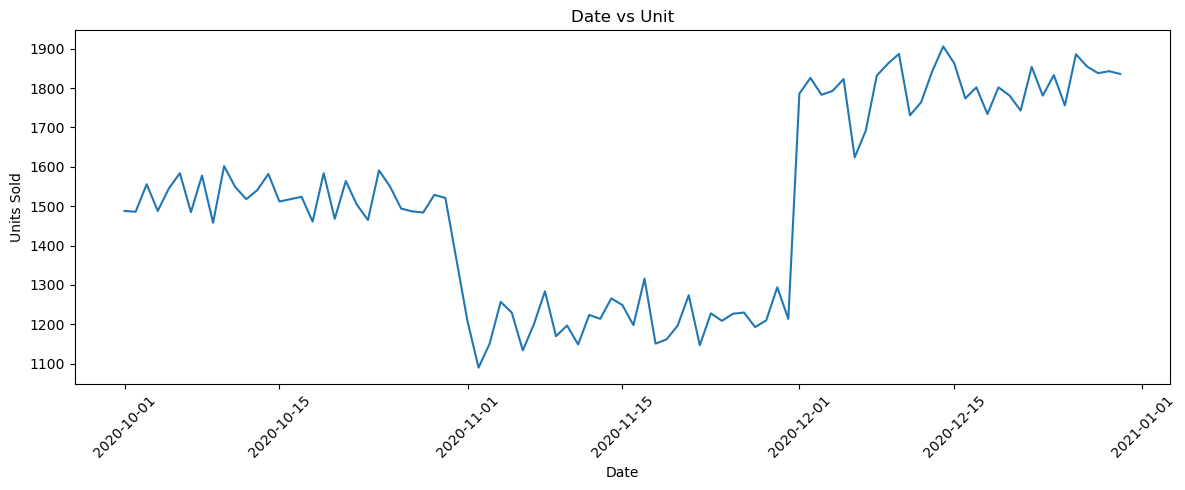

In [17]:
plt.figure(figsize = (12, 5))

plt.plot(daily_data.index, daily_data['Unit'])

plt.title('Date vs Unit')
plt.xlabel('Date')
plt.ylabel('Units Sold')

plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

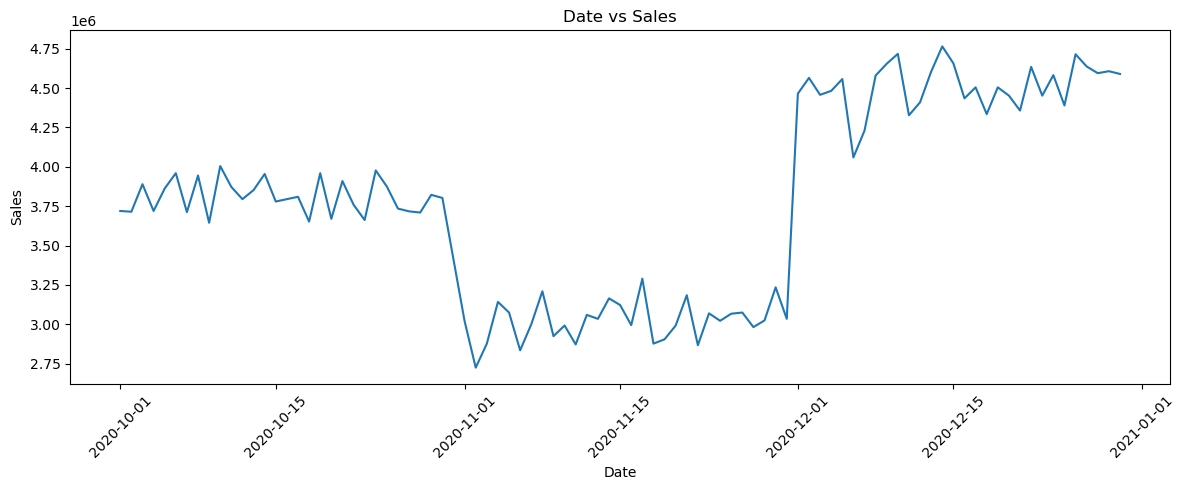

In [18]:
plt.figure(figsize = (12, 5))

plt.plot(daily_data.index, daily_data['Sales'])

plt.title('Date vs Sales')
plt.xlabel('Date')
plt.ylabel('Sales')

plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

In [19]:
df_date = df.set_index('Date')

df_oct = df_date.loc['2020-10-01' : '2020-10-31']
df_oct.head()

,Time,State,Group,Unit,Sales
Date,,,,,
2020-10-01,Morning,WA,Kids,8,20000
2020-10-01,Morning,WA,Men,8,20000
2020-10-01,Morning,WA,Women,4,10000
2020-10-01,Morning,WA,Seniors,15,37500
2020-10-01,Afternoon,WA,Kids,3,7500


In [20]:
df_nov = df_date.loc['2020-11-01' : '2020-11-30']
df_nov.head()

,Time,State,Group,Unit,Sales
Date,,,,,
2020-11-01,Morning,WA,Kids,4,10000
2020-11-01,Morning,WA,Men,6,15000
2020-11-01,Morning,WA,Women,4,10000
2020-11-01,Morning,WA,Seniors,7,17500
2020-11-01,Afternoon,WA,Kids,8,20000


In [21]:
df_dec = df_date.loc['2020-12-01' : '2020-12-31']
df_dec.head()

,Time,State,Group,Unit,Sales
Date,,,,,
2020-12-01,Morning,WA,Kids,9,22500
2020-12-01,Morning,WA,Men,11,27500
2020-12-01,Morning,WA,Women,15,37500
2020-12-01,Morning,WA,Seniors,13,32500
2020-12-01,Afternoon,WA,Kids,13,32500


In [22]:
print("October:", df_oct.shape)
print("November:", df_nov.shape)
print("December:", df_dec.shape)

October: (2520, 5)
November: (2520, 5)
December: (2520, 5)


In [23]:
df[['Unit', 'Sales']].describe()

,Unit,Sales
count,7560.000000,7560.000000
mean,18.005423,45013.558201
std,12.901403,32253.506944
min,2.000000,5000.000000
25%,8.000000,20000.000000
50%,14.000000,35000.000000
75%,26.000000,65000.000000
max,65.000000,162500.000000


In [24]:
df_oct[['Unit', 'Sales']].describe()

,Unit,Sales
count,2520.000000,2520.000000
mean,18.141270,45353.174603
std,11.944521,29861.302213
min,3.000000,7500.000000
25%,9.000000,22500.000000
50%,14.000000,35000.000000
75%,27.000000,67500.000000
max,50.000000,125000.000000


In [25]:
df_nov[['Unit', 'Sales']].describe()

,Unit,Sales
count,2520.000000,2520.000000
mean,14.394048,35985.119048
std,10.946470,27366.175823
min,2.000000,5000.000000
25%,6.000000,15000.000000
50%,10.000000,25000.000000
75%,22.000000,55000.000000
max,45.000000,112500.000000


In [26]:
df_dec[['Unit', 'Sales']].describe()

,Unit,Sales
count,2520.000000,2520.000000
mean,21.480952,53702.380952
std,14.554181,36385.451298
min,5.000000,12500.000000
25%,10.000000,25000.000000
50%,15.000000,37500.000000
75%,31.000000,77500.000000
max,65.000000,162500.000000


C:\Users\RISHI KUMAR SHARMA\AppData\Local\Temp\ipykernel_13624\3939155647.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df_oct['Unit'], df_nov['Unit'], df_dec['Unit']],


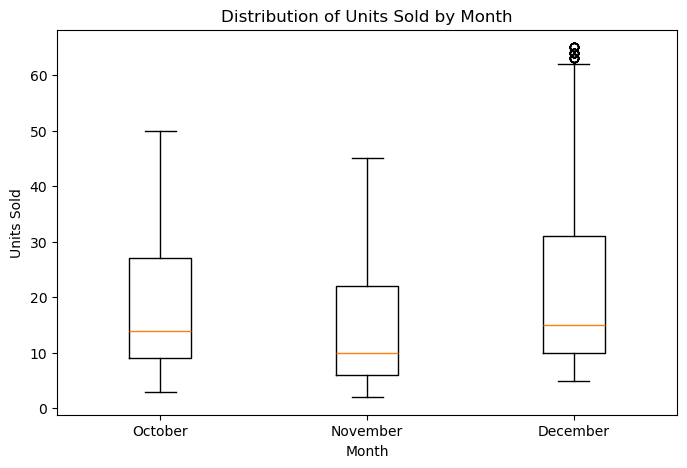

In [27]:
plt.figure(figsize = (8, 5))

plt.boxplot([df_oct['Unit'], df_nov['Unit'], df_dec['Unit']], 
           labels = ['October', 'November', 'December'])

plt.title('Distribution of Units Sold by Month')
plt.xlabel('Month')
plt.ylabel('Units Sold')

plt.show()

C:\Users\RISHI KUMAR SHARMA\AppData\Local\Temp\ipykernel_13624\2542013689.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df_oct['Sales'], df_nov['Sales'], df_dec['Sales']],


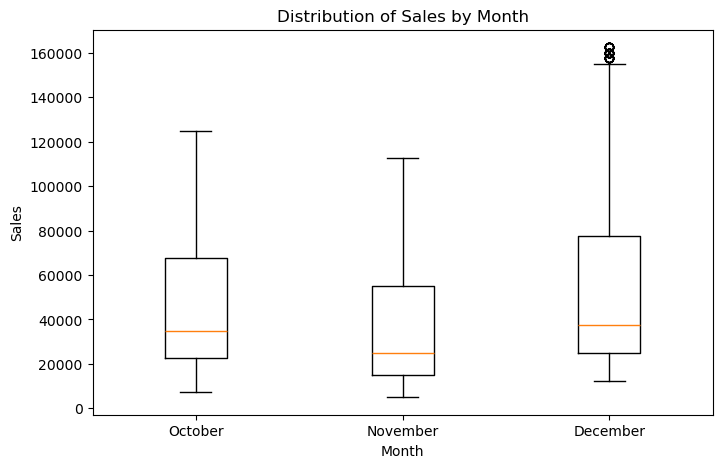

In [28]:
plt.figure(figsize = (8, 5))

plt.boxplot([df_oct['Sales'], df_nov['Sales'], df_dec['Sales']], 
           labels = ['October', 'November', 'December'])

plt.title('Distribution of Sales by Month')
plt.xlabel('Month')
plt.ylabel('Sales')

plt.show()

In [29]:
print("Total Units Sold:", df['Unit'].sum())
print("Total Sales:", df['Sales'].sum())

Total Units Sold: 136121
Total Sales: 340302500


In [30]:
print("October Units Sold:", df_oct['Unit'].sum())
print("November Units Sold:", df_nov['Unit'].sum())
print("December Units Sold:", df_dec['Unit'].sum())

October Units Sold: 45716
November Units Sold: 36273
December Units Sold: 54132


In [31]:
print("October Sales:", df_oct['Sales'].sum())
print("November Sales:", df_nov['Sales'].sum())
print("December Sales:", df_dec['Sales'].sum())

October Sales: 114290000
November Sales: 90682500
December Sales: 135330000


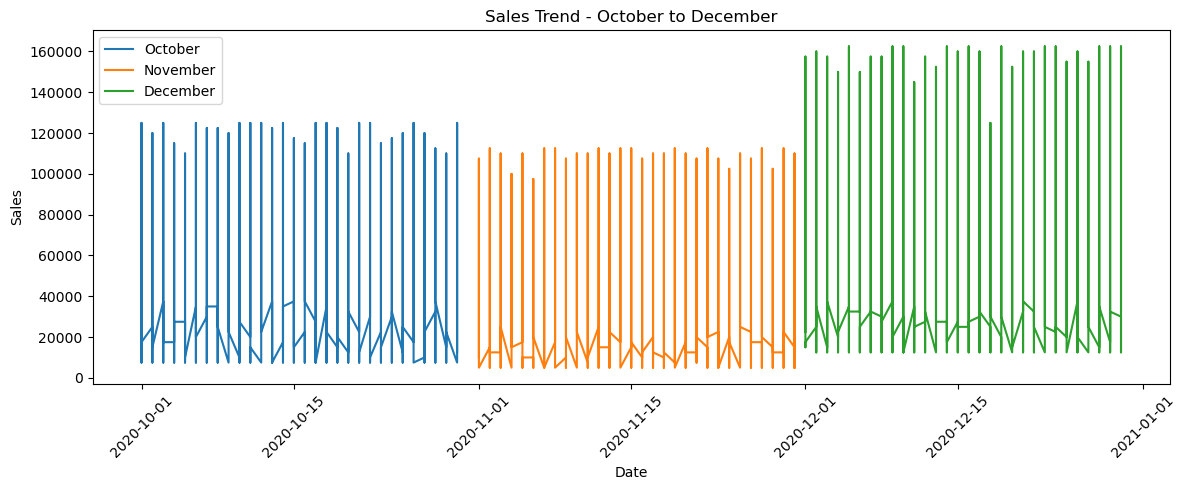

In [37]:
plt.figure(figsize = (12, 5))

plt.plot(df_oct.index, df_oct['Sales'], label = 'October')
plt.plot(df_nov.index, df_nov['Sales'], label = 'November')
plt.plot(df_dec.index, df_dec['Sales'], label = 'December')

plt.title('Sales Trend - October to December')
plt.xlabel('Date')
plt.ylabel('Sales')

plt.xticks(rotation = 45)
plt.legend()
plt.tight_layout()
plt.show()

In [40]:
print("==== COMPREHENSIVE SALES SNAPSHORT ====")

print("Total Units Sold:", df['Unit'].sum())
print("Total Sales:", df['Sales'].sum())

print("Average Units Sold:", df['Unit'].mean())
print("Average Sales:", df['Sales'].mean())

print("Minimum Units Sold:", df['Unit'].min())
print("Maximum Units Sold:", df['Unit'].max())

print("Minimum Sales:", df['Sales'].min())
print("Maximum Sales:", df['Sales'].max())

==== COMPREHENSIVE SALES SNAPSHORT ====
Total Units Sold: 136121
Total Sales: 340302500
Average Units Sold: 18.00542328042328
Average Sales: 45013.5582010582
Minimum Units Sold: 2
Maximum Units Sold: 65
Minimum Sales: 5000
Maximum Sales: 162500


In [41]:
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending = False)

state_sales

State
KY     105565000
NY      74970000
FL      58857500
CA      33417500
TX      22760000
AZ      22580000
 WA     22152500
Name: Sales, dtype: int64

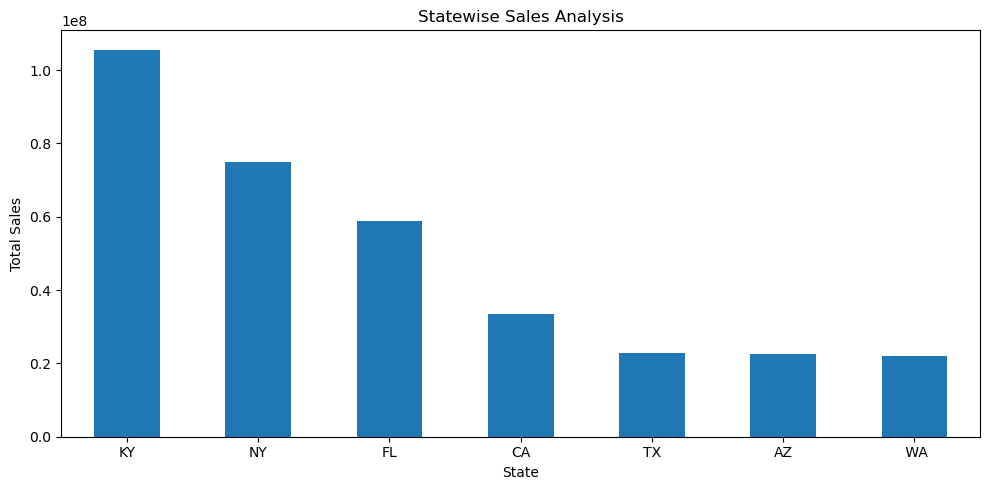

In [42]:
plt.figure(figsize = (10, 5))

state_sales.plot(kind = 'bar')

plt.title('Statewise Sales Analysis')
plt.xlabel('State')
plt.ylabel('Total Sales')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

In [43]:
group_sales = df.groupby('Group')[['Unit', 'Sales']].sum().sort_values('Sales', ascending = False)

group_sales

,Unit,Sales
Group,,
Men,34300,85750000
Women,34177,85442500
Kids,34029,85072500
Seniors,33615,84037500


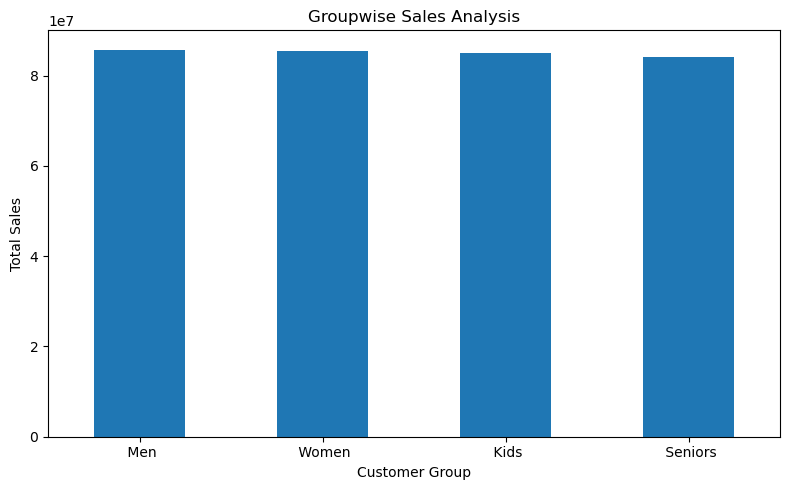

In [45]:
plt.figure(figsize = (8, 5))

group_sales['Sales'].plot(kind = 'bar')

plt.title('Groupwise Sales Analysis')
plt.xlabel('Customer Group')
plt.ylabel('Total Sales')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

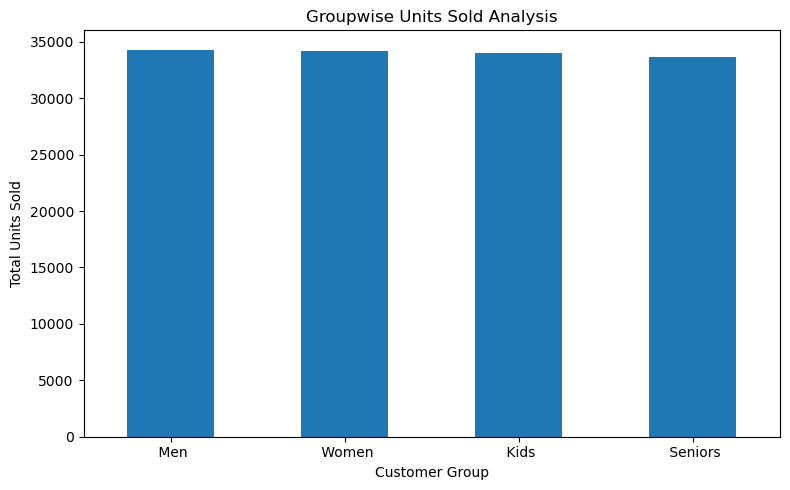

In [46]:
plt.figure(figsize = (8, 5))

group_sales['Unit'].plot(kind = 'bar')

plt.title('Groupwise Units Sold Analysis')
plt.xlabel('Customer Group')
plt.ylabel('Total Units Sold')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

In [47]:
time_sales = df.groupby('Time')['Sales'].sum().sort_values(ascending = False)

time_sales

Time
Morning      114207500
Afternoon    114007500
Evening      112087500
Name: Sales, dtype: int64

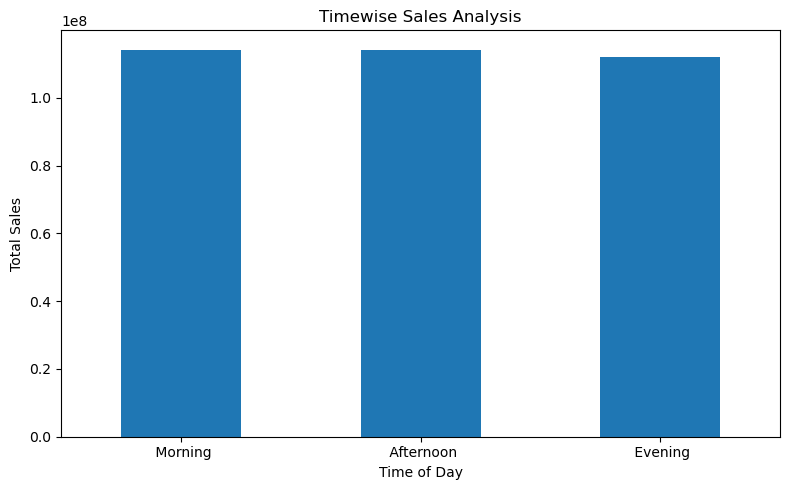

In [48]:
plt.figure(figsize = (8, 5))

time_sales.plot(kind = 'bar')

plt.title('Timewise Sales Analysis')
plt.xlabel('Time of Day')
plt.ylabel('Total Sales')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()